<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-I/blob/main/Extra/metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metricas algoritmos de clasificacion

In [ ]:
 from sklearn.datasets import load_breast_cancer
 from sklearn.datasets import load_diabetes
 from sklearn.neighbors import KNeighborsClassifier
 from sklearn.model_selection import train_test_split
 from sklearn.metrics import confusion_matrix
 from sklearn import metrics
 import pandas as pd
 import numpy as np
 from matplotlib import pyplot as plt
 import seaborn as sns
 sns.set_style('whitegrid')

In [ ]:
# Cargamos dataset de cancer de mama
data = load_breast_cancer()
# definimos matriz de diseño X y vector respuesta y
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = pd.Series(data['target'])
# Separamos en entrenamiento/test en razon 70/30 %
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)
# Creamos un KNN
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X_train, y_train)
# Obtenemos las predicciones del modelo con X_test
preds_train = modelo.predict(X_train)
preds = modelo.predict(X_test)


#Clase 1: benigno
#Clase 0: maligno




In [ ]:
y.value_counts()
#la mayoria de los casos es de la clase benigno

,count
1,357
0,212


In [ ]:
y.value_counts(normalize=True).round(2)*100

,proportion
1,63.0
0,37.0


In [ ]:
# Creando la matriz de confusión
cm = confusion_matrix(y_test, preds)
cm

array([[ 57,   6],
       [  4, 104]])

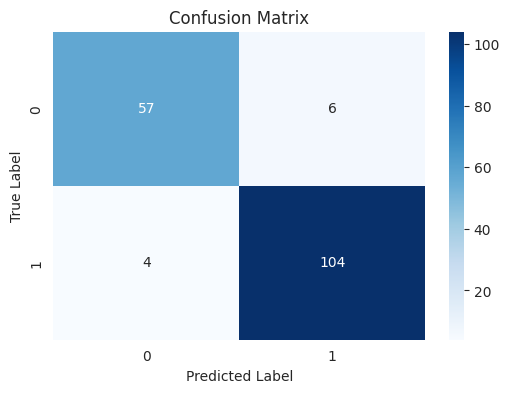

In [ ]:
# usando heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
#Clase 1: benigno
#Clase 0: maligno

In [ ]:
# Precision se evalua para cada categoria
precision_positiva = metrics.precision_score(y_test, preds, pos_label=1)
precision_negativa = metrics.precision_score(y_test, preds, pos_label=0)
precision_positiva, precision_negativa

(0.9454545454545454, 0.9344262295081968)

In [ ]:
metrics.recall_score(y_test, preds, pos_label=1), metrics.recall_score(y_test, preds, pos_label=0)


#El recall proporciona información sobre la capacidad del modelo para detectar correctamente los casos positivos en una clase específica

(0.9629629629629629, 0.9047619047619048)

In [ ]:
#probemos en train

accuracy = metrics.accuracy_score(y_train, preds_train)
accuracy

0.9472361809045227

In [ ]:
"""
Usar con cuidado el accuracy:

Imaginemos un escenario en el que tenemos un conjunto de datos desbalanceado, con el 95% de las muestras pertenecientes a la clase A y el 5%
de las muestras pertenecientes a la clase B. Un clasificador que siempre prediga la clase A tendría una exactitud del 95%,
lo cual parece ser un buen resultado. Sin embargo, este clasificador no está realmente aprendiendo a distinguir entre las dos clases
y simplemente se está inclinando hacia la clase mayoritaria.
"""

accuracy = metrics.accuracy_score(y_test, preds)
accuracy



0.9415204678362573

In [ ]:

f1_positivo = metrics.f1_score(y_train, preds_train, pos_label=1)
f1_negativo = metrics.f1_score(y_train, preds_train, pos_label=0)
f1_positivo, f1_negativo



(0.9587426326129665, 0.926829268292683)

In [ ]:
f1_positivo = metrics.f1_score(y_test, preds, pos_label=1)
f1_negativo = metrics.f1_score(y_test, preds, pos_label=0)
f1_positivo, f1_negativo

#no se evidencia una diferencia tan marcada en el f1_score, no hay sobreajuste ni subajuste

(0.9541284403669724, 0.9193548387096775)

In [ ]:
# Todas las metricas en un solo resumen
print(metrics.classification_report(y_train, preds_train))

              precision    recall  f1-score   support

           0       0.96      0.89      0.93       149
           1       0.94      0.98      0.96       249

    accuracy                           0.95       398
   macro avg       0.95      0.94      0.94       398
weighted avg       0.95      0.95      0.95       398



In [ ]:
# Todas las metricas en un solo resumen
print(metrics.classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        63
           1       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



##Se recomienda leer el siguiente material:

https://sitiobigdata.com/2019/01/19/machine-learning-metrica-clasificacion-parte-3/#

https://www.iartificial.net/precision-recall-f1-accuracy-en-clasificacion/



# Metrica algoritmos de regresion

In [ ]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Carguemos un dataset de ejemplo, revisar https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
diabetes_X, diabetes_y = load_diabetes(return_X_y=True)
diabetes_X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [ ]:
diabetes_y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(diabetes_X,diabetes_y,test_size=0.2,random_state=2)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
# crear el modelo
lr = LinearRegression()
# Ajustar el modelo con X_train y y_train
lr.fit(X_train,y_train)
# PRedecir con X_test
y_pred = lr.predict(X_test)

In [ ]:
y_pred_train = lr.predict(X_train)

In [ ]:
print("MAE",mean_absolute_error(y_train,y_pred_train))

MAE 42.91623353136606


In [ ]:

print("MAE",mean_absolute_error(y_test,y_pred))

MAE 45.213034190469024


Ventajas de MAE

- El MAE que obtiene está en la misma unidad que la variable de salida.
- Es más robusto a los valores atípicos.

Desventajas de MAE

-  El MAE no penaliza los errores grandes de manera proporcional. Cada error se trata de manera independiente y se calcula su promedio. Esto significa que el MAE puede no reflejar adecuadamente la importancia de errores significativos que pueden tener un impacto más grande en el problema en cuestión.

In [ ]:
from sklearn.metrics import mean_squared_error
print("MSE",mean_squared_error(y_test,y_pred))

MSE 3094.4566715660626


Ventajas de MSE

- Penaliza los errores grandes: A diferencia del MAE, el MSE penaliza de manera más significativa los errores grandes debido a que los errores se elevan al cuadrado.

Desventajas de MSE

- No intuitivo en términos de escala: El MSE se calcula tomando el promedio de los errores cuadráticos, lo que implica que la magnitud del MSE no está en la misma escala que los datos originales. Esto puede dificultar la interpretación directa del MSE y su comparación con los valores de referencia o umbrales establecidos..
- Si tiene valores atípicos en el conjunto de datos, los penaliza más y el MSE calculado es mayor. Entonces, en resumen, no es robusto a los valores atípicos que fueron una ventaja en MAE.

Ventajas de RMSE

- El valor de salida que obtiene está en la misma unidad que la variable de salida requerida, lo que facilita la interpretación de la pérdida.

Desventajas de RMSE

- No es tan resistente a los valores atípicos en comparación con MAE para realizar RMSE tenemos que NumPy función de raíz cuadrada sobre MSE.

In [ ]:
print("RMSE por numpy",np.sqrt(mean_squared_error(y_test,y_pred)))



RMSE por numpy 55.627840795469155


In [ ]:

print("RMSE por sklearn", mean_squared_error(y_test,y_pred,  squared=False))

RMSE por sklearn 55.627840795469155


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


R2 es una métrica que indica el rendimiento de su modelo, no la pérdida en un sentido absoluto.

Por el contrario, MAE y MSE dependen del contexto como hemos visto, mientras que la puntuación R2 es independiente del contexto.


In [ ]:
r2 = r2_score(y_train,y_pred_train)
print(r2)

0.5323672232993288


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(r2)

0.4399338661568968


se recomienda visitar esta web https://abdatum.com/ciencia/rmse